<a href="https://colab.research.google.com/github/Rasmy-r7/Research/blob/main/TinyBERT%26CodeBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 1: Install required packages
# Run this first, then restart runtime
#═══════════════════════════════════════════════════════════════
import os
os.environ["WANDB_DISABLED"] = "true"

!pip uninstall transformers accelerate peft -y -q
!pip install transformers==4.40.0 accelerate==0.27.2 -q

print("✅ Installation complete!")
print("   → Runtime → Restart Session → OK")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 46.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ Installation complete!
   → Runtime → Restart Session → OK


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 2: Import all libraries
# Run this immediately after restarting runtime
#═══════════════════════════════════════════════════════════════
import os, random, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    get_cosine_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm

os.environ["WANDB_DISABLED"] = "true"

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ All libraries imported!")
print(f"   Device : {device}")
if not torch.cuda.is_available():
    print("   ⚠️  No GPU! → Runtime → Change Runtime Type → T4 GPU")

✅ All libraries imported!
   Device : cuda


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 3: Upload and load all 3 CSV files
# Required columns: text, priority, priority_id
# priority     : High / Medium / Low  (string)
# priority_id  : 0 / 1 / 2           (integer)
#═══════════════════════════════════════════════════════════════
from google.colab import files

print("Upload your 3 CSV files:")
print("   1. train_combined.csv")
print("   2. val_combined.csv")
print("   3. test_combined.csv")

uploaded = files.upload()

train_df = pd.read_csv("train_combined.csv")
val_df   = pd.read_csv("val_combined.csv")
test_df  = pd.read_csv("test_combined.csv")

# ── Validate columns ─────────────────────────────────────────
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    assert 'text'        in df.columns, f"❌ Missing 'text' column in {name}"
    assert 'priority_id' in df.columns, f"❌ Missing 'priority_id' column in {name}"
    assert 'priority'    in df.columns, f"❌ Missing 'priority' column in {name}"

# ── Label config ─────────────────────────────────────────────
LABEL_MAP   = {'High': 0, 'Medium': 1, 'Low': 2}
INV_LABEL   = {0: 'High', 1: 'Medium', 2: 'Low'}
NUM_CLASSES = 3

# Ensure priority_id is integer
for df in [train_df, val_df, test_df]:
    df['priority_id'] = df['priority_id'].astype(int)

print(f"\n✅ All files loaded!")
print(f"   Train : {len(train_df):,} rows")
print(f"   Val   : {len(val_df):,} rows")
print(f"   Test  : {len(test_df):,} rows")
print(f"\n   Label distribution (train):")
print(train_df['priority'].value_counts().to_string())

Upload your 3 CSV files:
   1. train_combined.csv
   2. val_combined.csv
   3. test_combined.csv


Saving test_combined.csv to test_combined.csv
Saving val_combined.csv to val_combined.csv
Saving train_combined.csv to train_combined.csv

✅ All files loaded!
   Train : 23,274 rows
   Val   : 2,909 rows
   Test  : 2,910 rows

   Label distribution (train):
priority
Medium    9430
High      8550
Low       5294


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 4: Load TinyBERT and CodeBERT from Hugging Face
#
# TinyBERT : 4 layers, 312 dims
#            captures general NLP semantics of requirements
#
# CodeBERT : 12 layers, 768 dims
#            trained on code + NL pairs
#            captures technical/functional language patterns
#
# Both are frozen — used as fixed feature extractors
# Only the fusion classifier head is trained
#═══════════════════════════════════════════════════════════════
TINYBERT_NAME = "huawei-noah/TinyBERT_General_4L_312D"
CODEBERT_NAME = "microsoft/codebert-base"

print("Loading TinyBERT tokenizer and model...")
tinybert_tokenizer = AutoTokenizer.from_pretrained(TINYBERT_NAME)
tinybert_model     = AutoModel.from_pretrained(TINYBERT_NAME).to(device)

print("Loading CodeBERT tokenizer and model...")
codebert_tokenizer = AutoTokenizer.from_pretrained(CODEBERT_NAME)
codebert_model     = AutoModel.from_pretrained(CODEBERT_NAME).to(device)

# Freeze both backbones
for m in [tinybert_model, codebert_model]:
    for p in m.parameters():
        p.requires_grad = False
    m.eval()

# Embedding dimensions
TINYBERT_DIM = 312
CODEBERT_DIM = 768
FUSED_DIM    = TINYBERT_DIM + CODEBERT_DIM   # 1080

print(f"\n✅ Both models loaded and frozen!")
print(f"   TinyBERT  : {TINYBERT_DIM} dims  |  {TINYBERT_NAME}")
print(f"   CodeBERT  : {CODEBERT_DIM} dims  |  {CODEBERT_NAME}")
print(f"   Fused dim : {FUSED_DIM}  (concatenated)")

Loading TinyBERT tokenizer and model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]


✅ Both models loaded and frozen!
   TinyBERT  : 312 dims  |  huawei-noah/TinyBERT_General_4L_312D
   CodeBERT  : 768 dims  |  microsoft/codebert-base
   Fused dim : 1080  (concatenated)


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 5: FusionDataset
# Tokenizes each text TWICE:
#   → once with TinyBERT tokenizer
#   → once with CodeBERT tokenizer
# Both tokenizers have different vocabularies
# Uses priority_id as the integer label
#═══════════════════════════════════════════════════════════════
MAX_LENGTH = 128

class FusionDataset(Dataset):
    def __init__(self, dataframe, tiny_tokenizer,
                 code_tokenizer, max_length=MAX_LENGTH):
        self.texts          = dataframe['text'].tolist()
        self.labels         = dataframe['priority_id'].tolist()
        self.tiny_tokenizer = tiny_tokenizer
        self.code_tokenizer = code_tokenizer
        self.max_length     = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])

        # TinyBERT tokenization
        tiny_enc = self.tiny_tokenizer(
            text,
            max_length     = self.max_length,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )
        # CodeBERT tokenization
        code_enc = self.code_tokenizer(
            text,
            max_length     = self.max_length,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )

        return {
            'tiny_input_ids'     : tiny_enc['input_ids'].squeeze(0),
            'tiny_attention_mask': tiny_enc['attention_mask'].squeeze(0),
            'code_input_ids'     : code_enc['input_ids'].squeeze(0),
            'code_attention_mask': code_enc['attention_mask'].squeeze(0),
            'label'              : torch.tensor(
                                       self.labels[idx], dtype=torch.long
                                   )
        }

# Build datasets
BATCH_SIZE    = 32

train_dataset = FusionDataset(train_df, tinybert_tokenizer, codebert_tokenizer)
val_dataset   = FusionDataset(val_df,   tinybert_tokenizer, codebert_tokenizer)
test_dataset  = FusionDataset(test_df,  tinybert_tokenizer, codebert_tokenizer)

# Build dataloaders
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=64,
                           shuffle=False, num_workers=2, pin_memory=True)
test_loader   = DataLoader(test_dataset,  batch_size=64,
                           shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ Datasets and DataLoaders ready!")
print(f"   Train : {len(train_dataset):,} samples  |  {len(train_loader)} batches")
print(f"   Val   : {len(val_dataset):,} samples  |  {len(val_loader)} batches")
print(f"   Test  : {len(test_dataset):,} samples  |  {len(test_loader)} batches")
print(f"   Max length per tokenizer : {MAX_LENGTH} tokens")

✅ Datasets and DataLoaders ready!
   Train : 23,274 samples  |  728 batches
   Val   : 2,909 samples  |  46 batches
   Test  : 2,910 samples  |  46 batches
   Max length per tokenizer : 128 tokens


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 6: TinyBERT + CodeBERT Fusion Classifier
#
# Architecture:
#
#   text
#    ├──► TinyBERT [CLS] → (batch, 312)
#    └──► CodeBERT [CLS] → (batch, 768)
#                │
#           Concatenate  → (batch, 1080)
#                │
#          LayerNorm(1080)
#                │
#     Linear(1080→512) + GELU + Dropout(0.3)
#      + Residual(1080→512) ──────────────┘
#                │
#     Linear(512→256)  + GELU + Dropout(0.3)
#                │
#     Linear(256→128)  + GELU + Dropout(0.2)
#                │
#     Linear(128→3)    → logits
#                │
#        [High, Medium, Low]
#═══════════════════════════════════════════════════════════════
class TinyBERTCodeBERTFusionClassifier(nn.Module):
    def __init__(self, tiny_dim=312, code_dim=768,
                 num_classes=3,
                 dropout1=0.3, dropout2=0.3, dropout3=0.2):
        super().__init__()

        fused_dim = tiny_dim + code_dim   # 1080

        # Input normalisation
        self.layer_norm    = nn.LayerNorm(fused_dim)

        # Classifier layers
        self.fc1           = nn.Linear(fused_dim, 512)
        self.fc2           = nn.Linear(512, 256)
        self.fc3           = nn.Linear(256, 128)
        self.fc4           = nn.Linear(128, num_classes)

        # Residual skip: 1080 → 512
        self.residual_proj = nn.Linear(fused_dim, 512)

        self.dropout1      = nn.Dropout(dropout1)
        self.dropout2      = nn.Dropout(dropout2)
        self.dropout3      = nn.Dropout(dropout3)
        self.activation    = nn.GELU()

        self._init_weights()

    def _init_weights(self):
        for layer in [self.fc1, self.fc2, self.fc3,
                      self.fc4, self.residual_proj]:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.zeros_(layer.bias)

    def forward(self, tiny_emb, code_emb):
        # 1. Concatenate → (batch, 1080)
        fused    = torch.cat([tiny_emb, code_emb], dim=-1)

        # 2. Normalise
        fused    = self.layer_norm(fused)

        # 3. Layer 1 + residual
        residual = self.residual_proj(fused)
        x        = self.activation(self.fc1(fused))
        x        = self.dropout1(x + residual)

        # 4. Layer 2
        x        = self.activation(self.fc2(x))
        x        = self.dropout2(x)

        # 5. Layer 3
        x        = self.activation(self.fc3(x))
        x        = self.dropout3(x)

        # 6. Output logits
        return self.fc4(x)


classifier = TinyBERTCodeBERTFusionClassifier(
    tiny_dim    = TINYBERT_DIM,
    code_dim    = CODEBERT_DIM,
    num_classes = NUM_CLASSES
).to(device)

total_params     = sum(p.numel() for p in classifier.parameters())
trainable_params = sum(p.numel() for p in classifier.parameters()
                       if p.requires_grad)

print("✅ Fusion Classifier built!")
print(f"   Input     : TinyBERT({TINYBERT_DIM}) ⊕ CodeBERT({CODEBERT_DIM}) = {FUSED_DIM}")
print(f"   Layers    : {FUSED_DIM} → 512 → 256 → 128 → {NUM_CLASSES}")
print(f"   Residual  : 1080 → 512 skip connection")
print(f"   Total params    : {total_params:,}")
print(f"   Trainable params: {trainable_params:,}  (backbones frozen)")

✅ Fusion Classifier built!
   Input     : TinyBERT(312) ⊕ CodeBERT(768) = 1080
   Layers    : 1080 → 512 → 256 → 128 → 3
   Residual  : 1080 → 512 skip connection
   Total params    : 1,273,715
   Trainable params: 1,273,715  (backbones frozen)


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 7: Focal Loss + class weights + AdamW + cosine schedule
#
# Focal Loss  : focuses on hard Medium/High boundary examples
# Class weights: fixes imbalanced label distribution
# Cosine LR   : smooth learning rate decay
# Warmup      : prevents unstable early training
#═══════════════════════════════════════════════════════════════

# ── Class weights ────────────────────────────────────────────
raw_weights   = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.array([0, 1, 2]),
    y            = train_df['priority_id'].values
)
class_weights = torch.tensor(raw_weights, dtype=torch.float).to(device)

print("Class weights (balanced):")
print(f"   High   (0) : {raw_weights[0]:.4f}")
print(f"   Medium (1) : {raw_weights[1]:.4f}")
print(f"   Low    (2) : {raw_weights[2]:.4f}")

# ── Focal Loss ───────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.weight          = weight
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, labels):
        ce    = F.cross_entropy(
                    logits, labels,
                    weight          = self.weight,
                    label_smoothing = self.label_smoothing,
                    reduction       = 'none'
                )
        pt    = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()

criterion = FocalLoss(
    weight          = class_weights,
    gamma           = 2.0,
    label_smoothing = 0.1
)

# ── Optimizer ────────────────────────────────────────────────
EPOCHS       = 20
LR           = 3e-4
WEIGHT_DECAY = 0.01

optimizer    = torch.optim.AdamW(
    classifier.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY
)

# ── Cosine LR with warmup ────────────────────────────────────
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(0.1 * total_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

print(f"\n✅ Training config ready!")
print(f"   Loss       : Focal Loss γ=2.0 + label_smoothing=0.1")
print(f"   Optimizer  : AdamW  lr={LR}  wd={WEIGHT_DECAY}")
print(f"   Scheduler  : Cosine + {warmup_steps} warmup steps")
print(f"   Epochs     : {EPOCHS}")
print(f"   Batch size : {BATCH_SIZE}")

Class weights (balanced):
   High   (0) : 0.9074
   Medium (1) : 0.8227
   Low    (2) : 1.4654

✅ Training config ready!
   Loss       : Focal Loss γ=2.0 + label_smoothing=0.1
   Optimizer  : AdamW  lr=0.0003  wd=0.01
   Scheduler  : Cosine + 1456 warmup steps
   Epochs     : 20
   Batch size : 32


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 8: Extract [CLS] embeddings from both models
# [CLS] token at position 0 = sentence-level representation
# Both backbones are frozen so no gradients needed here
#═══════════════════════════════════════════════════════════════
def extract_embeddings(batch):
    """
    Input  : batch dict with tiny_* and code_* keys
    Output : tiny_emb (B, 312),  code_emb (B, 768)
    """
    with torch.no_grad():
        tiny_emb = tinybert_model(
            input_ids      = batch['tiny_input_ids'].to(device),
            attention_mask = batch['tiny_attention_mask'].to(device)
        ).last_hidden_state[:, 0, :]   # [CLS] → (B, 312)

        code_emb = codebert_model(
            input_ids      = batch['code_input_ids'].to(device),
            attention_mask = batch['code_attention_mask'].to(device)
        ).last_hidden_state[:, 0, :]   # [CLS] → (B, 768)

    return tiny_emb, code_emb

print("✅ Embedding extraction function ready!")
print(f"   TinyBERT [CLS] → (batch, {TINYBERT_DIM})")
print(f"   CodeBERT [CLS] → (batch, {CODEBERT_DIM})")
print(f"   Fused          → (batch, {FUSED_DIM})")

✅ Embedding extraction function ready!
   TinyBERT [CLS] → (batch, 312)
   CodeBERT [CLS] → (batch, 768)
   Fused          → (batch, 1080)


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 9: Full training loop with validation + early stopping
#
# Each epoch:
#   Train  → extract embeddings → fuse → classify → focal loss
#   Val    → evaluate → track best macro F1
#   Early stopping patience = 5 epochs
#═══════════════════════════════════════════════════════════════
PATIENCE = 5

history = {
    'train_loss': [], 'val_loss'  : [],
    'train_acc' : [], 'val_acc'   : [],
    'val_macro' : []
}

best_val_macro = 0.0
best_state     = None
patience_count = 0
scaler         = torch.cuda.amp.GradScaler()

print("=" * 70)
print("   TRAINING : TinyBERT ⊕ CodeBERT Feature Fusion Classifier")
print("=" * 70)
print(f"{'Epoch':>6} {'TrLoss':>9} {'VlLoss':>9} "
      f"{'TrAcc':>8} {'VlAcc':>8} {'MacroF1':>9}")
print("-" * 70)

for epoch in range(EPOCHS):

    # ────────────── TRAIN ───────────────────────────────────
    classifier.train()
    tr_loss, tr_preds, tr_labels = 0.0, [], []

    for batch in train_loader:
        labels             = batch['label'].to(device)
        tiny_emb, code_emb = extract_embeddings(batch)

        with torch.cuda.amp.autocast():
            logits = classifier(tiny_emb, code_emb)
            loss   = criterion(logits, labels)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        tr_loss += loss.item()
        tr_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        tr_labels.extend(labels.cpu().numpy())

    avg_tr_loss = tr_loss / len(train_loader)
    tr_acc      = accuracy_score(tr_labels, tr_preds)

    # ────────────── VALIDATE ────────────────────────────────
    classifier.eval()
    vl_loss, vl_preds, vl_labels = 0.0, [], []

    with torch.no_grad():
        for batch in val_loader:
            labels             = batch['label'].to(device)
            tiny_emb, code_emb = extract_embeddings(batch)

            with torch.cuda.amp.autocast():
                logits = classifier(tiny_emb, code_emb)
                loss   = criterion(logits, labels)

            vl_loss += loss.item()
            vl_preds.extend(logits.argmax(dim=-1).cpu().numpy())
            vl_labels.extend(labels.cpu().numpy())

    avg_vl_loss = vl_loss / len(val_loader)
    vl_acc      = accuracy_score(vl_labels, vl_preds)
    vl_macro    = f1_score(vl_labels, vl_preds, average='macro')

    # ────────────── LOG ─────────────────────────────────────
    history['train_loss'].append(avg_tr_loss)
    history['val_loss'].append(avg_vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['val_macro'].append(vl_macro)

    flag = ""
    if vl_macro > best_val_macro:
        best_val_macro = vl_macro
        best_state     = {k: v.cpu().clone()
                          for k, v in classifier.state_dict().items()}
        patience_count = 0
        flag           = "  ✅ best"
    else:
        patience_count += 1
        flag            = f"  (patience {patience_count}/{PATIENCE})"

    print(f"{epoch+1:>6} {avg_tr_loss:>9.4f} {avg_vl_loss:>9.4f} "
          f"{tr_acc:>8.4f} {vl_acc:>8.4f} {vl_macro:>9.4f}{flag}")

    if patience_count >= PATIENCE:
        print(f"\n⏹  Early stopping at epoch {epoch+1}")
        break

# Restore best checkpoint
classifier.load_state_dict(best_state)
classifier.to(device)
print(f"\n✅ Training complete!  Best val macro F1 : {best_val_macro:.4f}")

   TRAINING : TinyBERT ⊕ CodeBERT Feature Fusion Classifier
 Epoch    TrLoss    VlLoss    TrAcc    VlAcc   MacroF1
----------------------------------------------------------------------


/tmp/ipykernel_3498/3223812652.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler         = torch.cuda.amp.GradScaler()
/tmp/ipykernel_3498/3223812652.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3498/3223812652.py:49: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
/tmp/ipykernel_3498/3223812652.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args

     1    0.5123    0.3251   0.5407   0.6700    0.6727  ✅ best


/tmp/ipykernel_3498/3223812652.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3498/3223812652.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


     2    0.3469    0.3259   0.6433   0.6628    0.6614  (patience 1/5)


...

    18    0.2576    0.2627   0.7308   0.7195    0.7204  (patience 3/5)


/tmp/ipykernel_3498/3223812652.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3498/3223812652.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


    19    0.2566    0.2628   0.7298   0.7198    0.7211  (patience 4/5)


/tmp/ipykernel_3498/3223812652.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_3498/3223812652.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


    20    0.2567    0.2629   0.7272   0.7212    0.7232  (patience 5/5)

⏹  Early stopping at epoch 20

✅ Training complete!  Best val macro F1 : 0.7316


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 10: Full evaluation on held-out test set
#═══════════════════════════════════════════════════════════════
classifier.eval()
all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for batch in test_loader:
        labels             = batch['label'].to(device)
        tiny_emb, code_emb = extract_embeddings(batch)

        with torch.cuda.amp.autocast():
            logits = classifier(tiny_emb, code_emb)

        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = logits.argmax(dim=-1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── Metrics ──────────────────────────────────────────────────
acc         = accuracy_score(all_labels,  all_preds)
precision   = precision_score(all_labels, all_preds, average='macro')
recall      = recall_score(all_labels,    all_preds, average='macro')
macro_f1    = f1_score(all_labels,        all_preds, average='macro')
weighted_f1 = f1_score(all_labels,        all_preds, average='weighted')

print("=" * 65)
print("    FINAL EVALUATION — TinyBERT ⊕ CodeBERT Fusion")
print("=" * 65)
print(f"   Accuracy          : {acc:.4f}")
print(f"   Precision (macro) : {precision:.4f}")
print(f"   Recall    (macro) : {recall:.4f}")
print(f"   F1 Macro          : {macro_f1:.4f}")
print(f"   F1 Weighted       : {weighted_f1:.4f}")
print("=" * 65)

print("\nPer-class Classification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names = ['High', 'Medium', 'Low'],
    digits       = 4
))

cm    = confusion_matrix(all_labels, all_preds)
cm_df = pd.DataFrame(
    cm,
    index   = ['Actual High', 'Actual Medium', 'Actual Low'],
    columns = ['Pred High',   'Pred Medium',   'Pred Low']
)
print("Confusion Matrix:")
print(cm_df)

/tmp/ipykernel_3498/1704367612.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


    FINAL EVALUATION — TinyBERT ⊕ CodeBERT Fusion
   Accuracy          : 0.7419
   Precision (macro) : 0.7830
   Recall    (macro) : 0.7470
   F1 Macro          : 0.7462
   F1 Weighted       : 0.7393

Per-class Classification Report:
              precision    recall  f1-score   support

        High     0.6362    0.9130    0.7499      1069
      Medium     0.8794    0.5878    0.7046      1179
         Low     0.8333    0.7402    0.7840       662

    accuracy                         0.7419      2910
   macro avg     0.7830    0.7470    0.7462      2910
weighted avg     0.7796    0.7419    0.7393      2910

Confusion Matrix:
               Pred High  Pred Medium  Pred Low
Actual High          976           55        38
Actual Medium        426          693        60
Actual Low           132           40       490


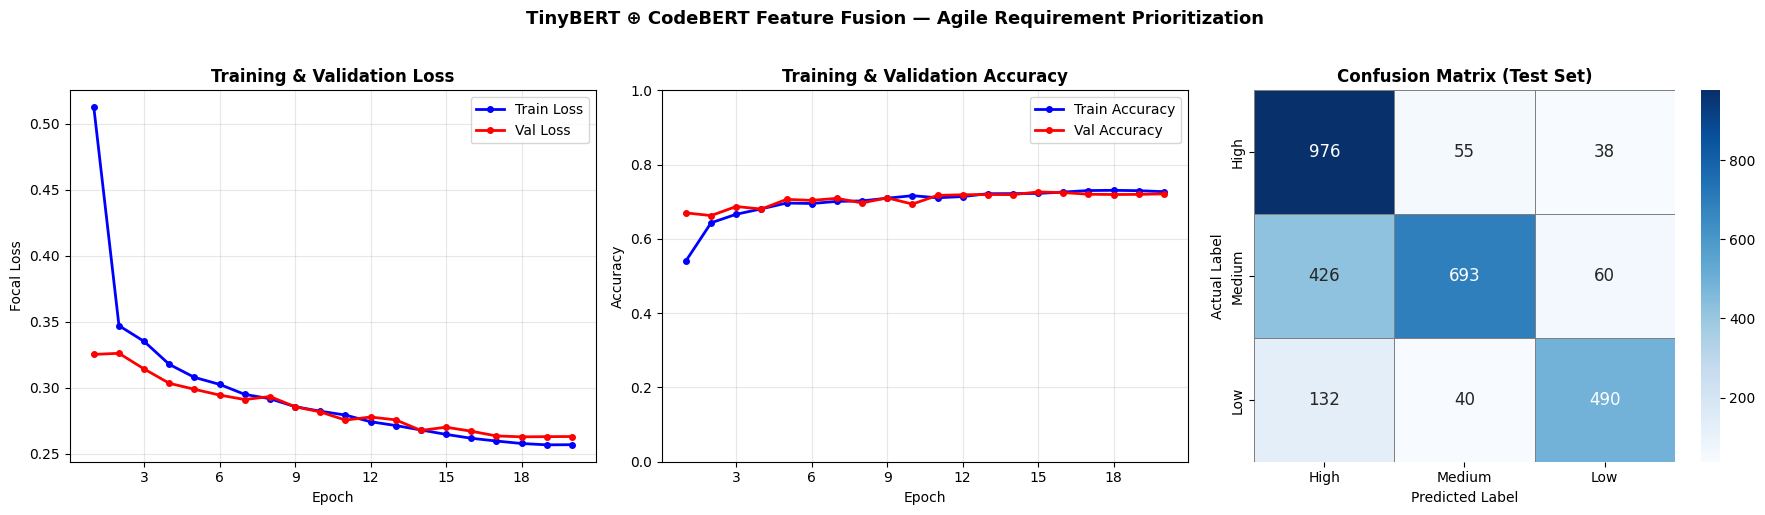

✅ Plots saved → fusion_results.png


In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 11: Plot loss, accuracy, confusion matrix
#═══════════════════════════════════════════════════════════════
epochs_ran = len(history['train_loss'])
x          = range(1, epochs_ran + 1)

fig, axes  = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    "TinyBERT ⊕ CodeBERT Feature Fusion — Agile Requirement Prioritization",
    fontsize=13, fontweight='bold', y=1.02
)

# ── Loss ─────────────────────────────────────────────────────
axes[0].plot(x, history['train_loss'], 'b-o', markersize=4,
             linewidth=2, label='Train Loss')
axes[0].plot(x, history['val_loss'],   'r-o', markersize=4,
             linewidth=2, label='Val Loss')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── Accuracy ─────────────────────────────────────────────────
axes[1].plot(x, history['train_acc'], 'b-o', markersize=4,
             linewidth=2, label='Train Accuracy')
axes[1].plot(x, history['val_acc'],   'r-o', markersize=4,
             linewidth=2, label='Val Accuracy')
axes[1].set_title('Training & Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# ── Confusion Matrix ─────────────────────────────────────────
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels = ['High', 'Medium', 'Low'],
    yticklabels = ['High', 'Medium', 'Low'],
    ax          = axes[2],
    linewidths  = 0.5,
    linecolor   = 'gray',
    annot_kws   = {"size": 12}
)
axes[2].set_title('Confusion Matrix (Test Set)', fontweight='bold')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('Actual Label')

plt.tight_layout()
plt.savefig("fusion_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plots saved → fusion_results.png")

In [ ]:
#═══════════════════════════════════════════════════════════════
# STEP 12: Save everything — do this immediately!
# Saves: weights, config, metrics, predictions, history
#═══════════════════════════════════════════════════════════════
import shutil
from google.colab import drive, files as colab_files

drive.mount('/content/drive')
os.makedirs("./fusion_model_v1", exist_ok=True)

# ── Classifier weights ───────────────────────────────────────
torch.save(
    classifier.state_dict(),
    "./fusion_model_v1/classifier_weights.pt"
)

# ── Config ───────────────────────────────────────────────────
config = {
    "tinybert_name" : TINYBERT_NAME,
    "codebert_name" : CODEBERT_NAME,
    "tinybert_dim"  : TINYBERT_DIM,
    "codebert_dim"  : CODEBERT_DIM,
    "fused_dim"     : FUSED_DIM,
    "num_classes"   : NUM_CLASSES,
    "max_length"    : MAX_LENGTH,
    "label_map"     : LABEL_MAP,
}
with open("./fusion_model_v1/config.json", "w") as f:
    json.dump(config, f, indent=2)

# ── Metrics ──────────────────────────────────────────────────
metrics = {
    "accuracy"        : round(acc,         4),
    "precision_macro" : round(precision,   4),
    "recall_macro"    : round(recall,      4),
    "f1_macro"        : round(macro_f1,    4),
    "f1_weighted"     : round(weighted_f1, 4),
    "best_val_macro"  : round(best_val_macro, 4),
}
with open("./fusion_model_v1/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# ── Training history ─────────────────────────────────────────
pd.DataFrame(history).to_csv(
    "./fusion_model_v1/training_history.csv", index=False
)

# ── Test predictions ─────────────────────────────────────────
pred_df = test_df.copy()
pred_df['predicted_label'] = [INV_LABEL[p] for p in all_preds]
pred_df['true_label']      = [INV_LABEL[l] for l in all_labels]
pred_df['prob_high']       = all_probs[:, 0].round(4)
pred_df['prob_medium']     = all_probs[:, 1].round(4)
pred_df['prob_low']        = all_probs[:, 2].round(4)
pred_df['correct']         = (
    pred_df['predicted_label'] == pred_df['true_label']
)
pred_df.to_csv("./fusion_model_v1/test_predictions.csv", index=False)

# ── Copy to Google Drive ─────────────────────────────────────
shutil.copytree(
    "./fusion_model_v1",
    "/content/drive/MyDrive/fusion_model_v1",
    dirs_exist_ok=True
)
shutil.copy(
    "fusion_results.png",
    "/content/drive/MyDrive/fusion_results.png"
)

print("✅ All files saved to Google Drive/fusion_model_v1/")
print("   classifier_weights.pt")
print("   config.json")
print("   metrics.json")
print("   training_history.csv")
print("   test_predictions.csv")
print("   fusion_results.png")

# ── Download to your computer ────────────────────────────────
colab_files.download("./fusion_model_v1/metrics.json")
colab_files.download("./fusion_model_v1/test_predictions.csv")
colab_files.download("fusion_results.png")

print("\n" + "=" * 65)
print("  RESEARCH SUMMARY")
print("=" * 65)
print(f"  Model    : TinyBERT({TINYBERT_DIM}) ⊕ CodeBERT({CODEBERT_DIM})")
print(f"  Task     : Agile Requirement Prioritization")
print(f"  Labels   : High / Medium / Low")
print(f"  Accuracy : {acc:.4f}")
print(f"  Macro F1 : {macro_f1:.4f}")
print("=" * 65)

Mounted at /content/drive
✅ All files saved to Google Drive/fusion_model_v1/
   classifier_weights.pt
   config.json
   metrics.json
   training_history.csv
   test_predictions.csv
   fusion_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  RESEARCH SUMMARY
  Model    : TinyBERT(312) ⊕ CodeBERT(768)
  Task     : Agile Requirement Prioritization
  Labels   : High / Medium / Low
  Accuracy : 0.7419
  Macro F1 : 0.7462
